### Initial actions

In [1]:
!pip install bitsandbytes unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.

In [2]:
import os
from huggingface_hub import login
from tqdm.notebook import tqdm

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from unsloth import FastVisionModel
from transformers import AutoProcessor, AutoModelForImageTextToText, AutoModelForMultimodalLM
from transformers.image_utils import load_image
import random
import bitsandbytes

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
from transformers import set_seed
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

seed_everything(42)

In [5]:
assert torch.cuda.is_available(), "CUDA is not available, but required!"

In [6]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

### First load and test VLM model

In [7]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit"
model, processor = FastVisionModel.from_pretrained(
    model_name=model_id,
    max_seq_length=2048,
    load_in_4bit=True,
    device_map="auto"
)

def generate_text(messages, images=None, model=model, processor=processor):
  text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False
  )
  inputs = processor(
      text=[text],
      images=images,
      padding=True,
      return_tensors="pt"
  )
  inputs = inputs.to(model.device)

  outputs = model.generate(**inputs, max_new_tokens=40)
  return processor.decode(outputs[0][inputs["input_ids"].shape[-1]:])

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]

generate_text(messages)

==((====))==  Unsloth 2026.9.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

'The animal on the candy is a **lion**.<|im_end|>'

### Load datasets

In [8]:
from datasets import load_dataset

train_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="train")
val_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="validation")
test_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="test")

README.md:   0%|          | 0.00/5.73k [00:00<?, ?B/s]

human_handwrite/train-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 16.2MB            

human_handwrite/train-00000-of-00001.par(…): downloading bytes:           |  0.00B            

human_handwrite/validation-00000-of-0000(…): reconstructing file:   0%|          |  0.00B /  961kB            

human_handwrite/validation-00000-of-0000(…): downloading bytes:           |  0.00B            

human_handwrite/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  906kB            

human_handwrite/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/68 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70 [00:00<?, ? examples/s]

### Test model

In [9]:
from IPython.display import display, Math

In [10]:
import re

def clean_prediction(text: str) -> str:
    text = text.strip()

    # Remove Markdown code fences
    text = re.sub(r"^```(?:latex|tex)?\s*", "", text)
    text = re.sub(r"\s*```", "", text)

    # Remove chat special tokens
    text = text.replace("<|im_end|>", "")
    text = text.replace("<|endoftext|>", "")

    return text.strip()

In [11]:
image = test_dataset_linxy[2]['image']
zero_shot_prompt = """
Convert the handwritten mathematical formula in the image into LaTeX.
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": zero_shot_prompt}
        ]
    },
]

answer = generate_text(messages, [image])
answer = clean_prediction(answer)
print(answer)
print('-----------------------------------')
print('Example: ')
print(test_dataset_linxy[2]['text'])

\frac{2 \tan \alpha}{1 - \tan^2 \alpha}
-----------------------------------
Example: 
\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \alpha }


In [12]:
display(Math(test_dataset_linxy[2]['text']))

<IPython.core.display.Math object>

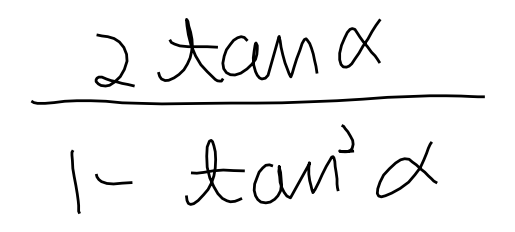

In [13]:
image

In [14]:
display(Math(answer))

<IPython.core.display.Math object>

### Calculate metrics for zero-shot inference

In [15]:
!pip install rouge_score sacrebleu jiwer

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3da28065b3b86f5c315af626c18f7990176ec8424881fffa9fb66883f8244e1f
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge_score


In [16]:
from rouge_score import rouge_scorer
import sacrebleu
import jiwer
from tqdm.notebook import tqdm

In [17]:
def prompt_generation(
    mode="_0shot",
    examples=None
):
    base_prompt = """
    Convert the handwritten mathematical formula in the image into LaTeX.
    """

    prompt = [
        {
            "role": "user",
            "content" : [

            ]
        }
    ]
    if mode == "_0shot":
      examples=[]
      prompt = [
          { "role": "user",
           "content" : [
               {"type" : "image"},
               {"type" : "text",  "text" : base_prompt}
               ]
            }
          ]
    elif mode == "_1shot":
      example_item = examples[0]
      example_image = example_item['image']
      example_text = example_item['text']

      prompt = [
        {
          "role": "user",
          "content": [
              {"type": "image"},
              {"type": "text", "text": base_prompt}
          ]
        },
        {
          "role": "assistant",
          "content": [
              {"type": "text", "text": example_text}
          ]
        },
        {
          "role": "user",
          "content": [
              {"type": "image"},
              {"type": "text", "text": base_prompt}
          ]
        }
      ]
      examples = [example_image]

    return [prompt, examples]

In [18]:
def generate_prediction(
    model,
    processor,
    images,
    prompt,
    device,
    max_new_tokens=150,
):
    inputs = processor(
        text=prompt,
        images=images,
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    prediction = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    )[0]

    return prediction

In [19]:
def normalize_prediction(text: str) -> str:
    text = text.strip()

    # Remove user/assistance construction
    text = re.sub(r"^(?:user)[\s*\S*\s*]*(?:assistant)\s*", "", text)

    # Remove Markdown code fences
    text = re.sub(r"```(?:latex|tex)?\s*", "", text)
    text = re.sub(r"\s*```", "", text)

    # Remove chat special tokens
    text = text.replace("<|im_end|>", "")
    text = text.replace("<|endoftext|>", "")

    return text.strip()

In [20]:
def normalize_reference(text: str) -> str:
    return text.strip()

In [21]:
def evaluate_model(
    model,
    processor,
    dataset,
    device,
    prompt,
    examples=None,
    max_new_tokens=150,
):
    results = []
    prompt, examples = prompt
    print("Evaluating model on the given dataset")
    for idx, item in enumerate(tqdm(dataset)):
        raw_prediction = generate_prediction(
            model=model,
            processor=processor,
            images=examples + [item["image"]],
            prompt=prompt,
            device=device,
            max_new_tokens=max_new_tokens,
        )
        prediction = normalize_prediction(raw_prediction)
        reference = normalize_reference(item["text"])

        results.append({
            "index": idx,
            "prediction": prediction,
            "reference": reference,
            "cer": jiwer.cer(reference, prediction),
        })

    return pd.DataFrame(results)

In [22]:
prompt = prompt_generation()

In [23]:
results = evaluate_model(model, processor, test_dataset_linxy, device=model.device, prompt=prompt)

Evaluating model on the given dataset


  0%|          | 0/70 [00:00<?, ?it/s]

In [24]:
zero_shot_cer = results["cer"].mean()
print("zero-shot cer: ", zero_shot_cer)

zero-shot cer:  0.37381271240747904


In [25]:
results.sort_values("cer", ascending=False).head(10)

,index,prediction,reference,cer
44,44,(\lambda^3 - \lambda^2 - \lambda)(2\lambda - 7),\left( x ^ { 3 } - x ^ { 2 } - x \right) \left...,0.746032
19,19,(\lambda^3 - \lambda^2 - \lambda)(2\lambda - 7),\left( x ^ { 3 } - x ^ { 2 } - x \right) \left...,0.746032
56,56,x^i + 2jxk^3 - 2^{1/1},x ^ { i + 2 j \times k ^ { 3 } - 2 \frac { j }...,0.685185
23,23,(x^3 - x^2 - x)(2x - 7),\left( x ^ { 3 } - x ^ { 2 } - x \right) \left...,0.634921
7,7,\frac{1}{a}F(ax+b)+c,\frac { 1 } { a } F \left( a x + b \right) + C,0.586957
57,57,"\int (2^n - 3e^x) \, dx",\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.574468
48,48,x^{i+2} \times k^3 - 2^{i},x ^ { i + 2 j \times k ^ { 3 } - 2 \frac { j }...,0.555556
6,6,"\int (2^x - 3e^x) \, dx",\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.553191
31,31,"\int (2^x - 3e^x) \, dx",\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.553191
14,14,x_1 + x_2 = x_3,x _ { 1 } + x _ { 2 } = x _ { 3 },0.545455


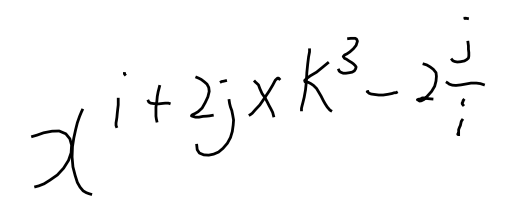

In [26]:
test_dataset_linxy[56]["image"]

In [27]:
test_dataset_linxy[56]["text"]

'x ^ { i + 2 j \\times k ^ { 3 } - 2 \\frac { j } { i } }'

In [28]:
display(Math(test_dataset_linxy[56]["text"]))

<IPython.core.display.Math object>

In [29]:
display(Math(results.iloc[56, :]["prediction"]))

<IPython.core.display.Math object>

zero-shot cer: 0.37381271240747904

### Calculate metrics for one-shot inference

In [30]:
example_image_index = 377

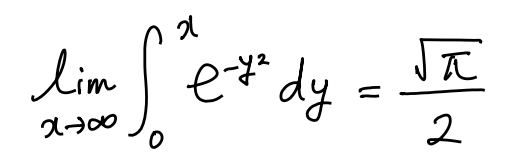

In [31]:
train_dataset_linxy[example_image_index]["image"]

In [32]:
train_dataset_linxy[example_image_index]["text"]

'\\lim _ { x \\rightarrow \\infty } \\int _ { 0 } ^ { x } e ^ { - y ^ { 2 } } d y = \\frac { \\sqrt \\pi } 2'

In [33]:
display(Math(train_dataset_linxy[example_image_index]["text"]))

<IPython.core.display.Math object>

In [34]:
example_pred = generate_prediction(model=model, processor=processor, images=[train_dataset_linxy[example_image_index]["image"]], prompt=prompt[0], device=model.device)
example_pred = normalize_prediction(example_pred)

In [35]:
example_pred

'\\lim_{x \\to \\infty} \\int_0^x e^{-y^2} dy = \\frac{\\sqrt{\\pi}}{2}'

In [36]:
display(Math(example_pred))

<IPython.core.display.Math object>

In [37]:
jiwer.cer(normalize_reference(train_dataset_linxy[example_image_index]["text"]), example_pred)

0.42

In [38]:
example = train_dataset_linxy[example_image_index]
prompt_1shot = prompt_generation(mode="_1shot", examples=[example])
results_1shot = evaluate_model(model, processor, test_dataset_linxy, device=model.device, prompt=prompt_1shot)

Evaluating model on the given dataset


  0%|          | 0/70 [00:00<?, ?it/s]

In [39]:
one_shot_cer = results_1shot["cer"].mean()
print("one-shot cer: ", one_shot_cer)

one-shot cer:  0.23301768403168732


In [40]:
results_1shot.sort_values("cer", ascending=False).head(10)

,index,prediction,reference,cer
22,22,\lim _ { x \rightarrow \infty } \int _ { 0 } ^...,x ^ { i + 2 j \times k ^ { 3 } - 2 \frac { j }...,1.185185
6,6,$$\n\int (2^x - 3e^x) dx\n$$,\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.702128
56,56,x^i + 2jxk^3 - 2^{1/1},x ^ { i + 2 j \times k ^ { 3 } - 2 \frac { j }...,0.685185
31,31,$$\n\int (2^{x} - 3e^{x}) dx\n$$,\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.617021
0,0,\sqrt{b^2 - 4ac},\sqrt { b ^ { 2 } - 4 a c },0.407407
41,41,\sqrt{b^2 - 4ac},\sqrt { b ^ { 2 } - 4 a c },0.407407
16,16,\sqrt{b^2 - 4ac},\sqrt { b ^ { 2 } - 4 a c },0.407407
66,66,\sqrt{b^2 - 4ac},\sqrt { b ^ { 2 } - 4 a c },0.407407
50,50,$$ \sin x - \sin y - \sin (x - y) $$,\sin x - \sin y - \sin \left( x - y \right),0.395349
25,25,$$ \sin x - \sin y - \sin (x - y) $$,\sin x - \sin y - \sin \left( x - y \right),0.395349


Zero-shot cer: 0.37381271240747904
1) one-shot cer (image 0 - example): 0.22864474284223332 (выбираем просто первый же объект из трейна. Также у этого объекта довольно простая структура и модель в zero-shot конфигурации уже выводит верный latex код)  
2) one-shot cer (image 24 - example): 0.21430140965630148 (выбираем объект, где в latex коде встречаются команды \left и \right
3) one-shot cer (image 378 - example): 0.23301768403168732 (выбираем объект со сложной структурой latex кода (множество команд, есть дробь, интеграл, степень)

### Supervised fine-tuning (SFT) using linxy/LaTeX_OCR:train

#### Qwen3-VL-2B-Instruct

In [41]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [42]:
from unsloth import FastVisionModel

model_id = "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit"

model, tokenizer = FastVisionModel.from_pretrained(
    model_id,
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    device_map="auto"
)

==((====))==  Unsloth 2026.9.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [43]:
base_prompt = """
    Convert the handwritten mathematical formula in the image into LaTeX.
    """

def convert_to_conversation(sample):
    conversation = [
        {
          "role": "user",
          "content": [
              {"type": "image", "image" : sample["image"]},
              {"type": "text", "text": base_prompt}
          ]
        },
        {
          "role": "assistant",
          "content": [
              {"type": "text", "text": sample["text"]}
          ]
        }
      ]
    return { "messages" : conversation }

train_ds1 = train_dataset_linxy.map(convert_to_conversation, remove_columns=train_dataset_linxy.column_names)
eval_ds1 = val_dataset_linxy.map(convert_to_conversation, remove_columns=val_dataset_linxy.column_names)
test_ds1 = test_dataset_linxy.map(convert_to_conversation, remove_columns=test_dataset_linxy.column_names)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

In [44]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [45]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None
)

In [46]:
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_ds1,
    eval_dataset = eval_ds1,
    args = SFTConfig(
        num_train_epochs = 2,
        learning_rate = 1e-4,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        eval_strategy = "steps",
        eval_steps = 50,
        logging_steps = 50,
        eval_on_start = True,
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [47]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
4.592 GB of memory reserved.


In [48]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,200 | Num Epochs = 2 | Total steps = 300
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Step,Training Loss,Validation Loss
0,No log,2.956458
50,0.936270,0.023433
100,0.031273,0.013031
150,0.021252,0.006913
200,0.011973,0.006815
250,0.011418,0.006209
300,0.010965,0.005783


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-300/tokenizer_config.json.


In [49]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

596.8609 seconds used for training.
9.95 minutes used for training.
Peak reserved memory = 5.559 GB.
Peak reserved memory for training = 0.967 GB.
Peak reserved memory % of max memory = 38.172 %.
Peak reserved memory for training % of max memory = 6.64 %.


In [50]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [51]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=3072, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

#### Calculate metrics for SFT model (linxy dataset)

In [52]:
prompt = prompt_generation()
results_ft1 = evaluate_model(model=model, processor=tokenizer, dataset=test_dataset_linxy, device=model.device, prompt=prompt)

Evaluating model on the given dataset


  0%|          | 0/70 [00:00<?, ?it/s]

In [53]:
fine_tune_1_cer = results_ft1["cer"].mean()
print("fine-tune linxy cer: ", fine_tune_1_cer)

fine-tune linxy cer:  0.0021563342318059297


In [54]:
results_ft1.sort_values("cer", ascending=False).head(10)

,index,prediction,reference,cer
62,62,\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } },\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 ...,0.075472
11,11,\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } },\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 ...,0.075472
2,2,\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \al...,\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \al...,0.000000
3,3,\lim _ { x \rightarrow - 1 } \frac { x ^ { 3 }...,\lim _ { x \rightarrow - 1 } \frac { x ^ { 3 }...,0.000000
0,0,\sqrt { b ^ { 2 } - 4 a c },\sqrt { b ^ { 2 } - 4 a c },0.000000
1,1,\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ...,\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ...,0.000000
5,5,\lim _ { x \rightarrow \frac { \pi } { 2 } + 0...,\lim _ { x \rightarrow \frac { \pi } { 2 } + 0...,0.000000
4,4,1 + \frac { 1 } { 1 ! } + \frac { 1 } { 2 ! } ...,1 + \frac { 1 } { 1 ! } + \frac { 1 } { 2 ! } ...,0.000000
8,8,\frac { \sin B + \sin C } { \cos B + \cos C },\frac { \sin B + \sin C } { \cos B + \cos C },0.000000
6,6,\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,\int \left( 2 ^ { x } - 3 e ^ { x } \right) d x,0.000000


In [55]:
model.push_to_hub_merged("Azaper/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit-linxy",
                         tokenizer)

config.json:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in Azaper/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit-linxy/tokenizer_config.json.
No files have been modified since last commit. Skipping to prevent empty commit.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t-linxy/model.safetensors:   1%|          | 24.0MB / 4.26GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:46<00:00, 166.11s/it]


Unsloth: Merge process complete. Saved to `/content/Azaper/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit-linxy`


Fine-tune linxy hyperparameters
1. epochs = 2, learning_rate = 1e-5  
cer: 0.04110369629146079  
2. epochs = 2, learning_rate = 1e-4  
cer: 0.0021563342318059297  
3. epochs = 2, learning_rate = 1e-3  
cer: 0.003234501347708895

### SFT model on 2 datasets (linxy + deepcopy)

In [56]:
print("linxy train len: ", len(train_dataset_linxy))
print("linxy val len: ", len(val_dataset_linxy))
print("linxy test len: ", len(test_dataset_linxy))

linxy train len:  1200
linxy val len:  68
linxy test len:  70


In [57]:
train_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split=f"train[:{len(train_dataset_linxy)}]")
val_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split=f"val[:{len(val_dataset_linxy)}]")
test_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split=f"test[:{len(test_dataset_linxy)}]")

README.md:   0%|          | 0.00/3.27k [00:00<?, ?B/s]

data/train-00000-of-00003-ab0ae6b9fa4a3f(…): reconstructing file:   0%|          |  0.00B /  373MB            

data/train-00000-of-00003-ab0ae6b9fa4a3f(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-589d2b65116e09(…): reconstructing file:   0%|          |  0.00B /  374MB            

data/train-00001-of-00003-589d2b65116e09(…): downloading bytes:           |  0.00B            

...

data/val-00000-of-00001-184984e66f80ed7a(…): reconstructing file:   0%|          |  0.00B / 81.6MB            

data/val-00000-of-00001-184984e66f80ed7a(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/229864 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7644 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/15674 [00:00<?, ? examples/s]

In [58]:
base_prompt = """
    Convert the handwritten mathematical formula in the image into LaTeX.
    """

def convert_to_conversation_deepcopy(sample):
    conversation = [
        {
          "role": "user",
          "content": [
              {"type": "image", "image" : sample["image"]},
              {"type": "text", "text": base_prompt}
          ]
        },
        {
          "role": "assistant",
          "content": [
              {"type": "text", "text": sample["latex"]}
          ]
        }
      ]
    return { "messages" : conversation }

In [59]:
train_ds2 = train_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=train_dataset_deepcopy.column_names)
eval_ds2 = val_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=val_dataset_deepcopy.column_names)
test_ds2 = test_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=test_dataset_deepcopy.column_names)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

In [60]:
from datasets import concatenate_datasets

train_ds2 = concatenate_datasets([train_ds1, train_ds2])
eval_ds2 = concatenate_datasets([eval_ds1, eval_ds2])
test_ds2 = concatenate_datasets([test_ds1, test_ds2])

In [61]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [62]:
from unsloth import FastVisionModel

model_id = "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit"

model, tokenizer = FastVisionModel.from_pretrained(
    model_id,
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    device_map="auto"
)

==((====))==  Unsloth 2026.9.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [63]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None
)

In [64]:
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_ds2,
    eval_dataset = eval_ds2,

    args = SFTConfig(
        num_train_epochs = 2,
        learning_rate = 1e-3,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        eval_strategy = "steps",
        eval_steps = 50,
        logging_steps = 50,
        eval_on_start = True,
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512
Unsloth: not enough free memory for dataset tokenization workers (~1GB each); tokenizing in-process.


In [65]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
6.973 GB of memory reserved.


In [66]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,400 | Num Epochs = 2 | Total steps = 600
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Step,Training Loss,Validation Loss
0,No log,3.672866
50,0.659264,0.127806
100,0.119496,0.132477
150,0.117009,0.104872
200,0.098089,0.092410
250,0.083516,0.091181
300,0.096543,0.089250
350,0.049418,0.081339
400,0.043074,0.080822
450,0.031032,0.074522


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-600/tokenizer_config.json.


In [67]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1143.1142 seconds used for training.
19.05 minutes used for training.
Peak reserved memory = 7.91 GB.
Peak reserved memory for training = 0.937 GB.
Peak reserved memory % of max memory = 54.316 %.
Peak reserved memory for training % of max memory = 6.434 %.


In [68]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [69]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=3072, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

In [70]:
prompt = prompt_generation()
results_ft2 = evaluate_model(model=model, processor=tokenizer, dataset=test_dataset_linxy, device=model.device, prompt=prompt)

Evaluating model on the given dataset


  0%|          | 0/70 [00:00<?, ?it/s]

In [71]:
fine_tune_2_cer = results_ft2["cer"].mean()
print("fine-tune linxy+deepcopy cer: ", fine_tune_2_cer)

fine-tune linxy+deepcopy cer:  0.004333402446609993


In [72]:
results_ft2.sort_values("cer", ascending=False).head(10)

,index,prediction,reference,cer
61,61,3 0 \times 2 9 x ^ { 2 } 8,3 0 \times 2 9 x ^ { 2 8 },0.076923
11,11,\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } },\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 ...,0.075472
37,37,\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } },\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 ...,0.075472
62,62,\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } },\sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 ...,0.075472
0,0,\sqrt { b ^ { 2 } - 4 a c },\sqrt { b ^ { 2 } - 4 a c },0.000000
1,1,\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ...,\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ...,0.000000
5,5,\lim _ { x \rightarrow \frac { \pi } { 2 } + 0...,\lim _ { x \rightarrow \frac { \pi } { 2 } + 0...,0.000000
4,4,1 + \frac { 1 } { 1 ! } + \frac { 1 } { 2 ! } ...,1 + \frac { 1 } { 1 ! } + \frac { 1 } { 2 ! } ...,0.000000
3,3,\lim _ { x \rightarrow - 1 } \frac { x ^ { 3 }...,\lim _ { x \rightarrow - 1 } \frac { x ^ { 3 }...,0.000000
2,2,\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \al...,\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \al...,0.000000


In [73]:
model.push_to_hub_merged("Azaper/SmolVLM-256M-SFT-linxy-deepcopy",
                         tokenizer,
                         commit_message="finetuning using train dataset with structure: len(linxy):len(deepcopy)=1:1")

No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in Azaper/SmolVLM-256M-SFT-linxy-deepcopy/tokenizer_config.json.
No files have been modified since last commit. Skipping to prevent empty commit.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eepcopy/model.safetensors:   0%|          | 7.90MB / 4.26GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [04:16<00:00, 256.60s/it]


Unsloth: Merge process complete. Saved to `/content/Azaper/SmolVLM-256M-SFT-linxy-deepcopy`


Fine-tune linxy+deepcopy hyperparameters
1. epochs = 2, learning_rate = 1e-5  
cer: 0.039679818771650804  
2. epochs = 2, learning_rate = 1e-4  
cer: 0.009299191374663071
3. epochs = 2, learning_rate = 1e-3  
cer: 0.004333402446609993
4. epochs = 2, learning_rate = 1e-3, linxy:deepcopy=1:4  
cer: 0.003234501347708895  
5. epochs = 2, learning_rate = 1e-4, linxy:deepcopy=1:4  
cer: 0.006907931840546395

### Results
В итоге лучший результат показала модель, дообученная на одном датасете linxy c гиперпараметрами epochs = 2, learning_rate = 1e-4 (остальные параметры не менялись в экспериментах). Значение метрики CER на тестовом датасете linxy:
0.0021563342318059297. Модель дообучалась на T4 GPU от Google colab около 10 минут.